<a href="https://colab.research.google.com/github/aryancodes12/Advance-Machine-Learning/blob/main/Penguin_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [199]:
filepath = "/content/drive/MyDrive/CDPL SEM 3/dataset/penguins.csv"

import pandas as pd

data = pd.read_csv(filepath)
df = pd.DataFrame(data)

In [200]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [201]:
df.shape

(344, 5)

In [202]:
df.columns

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [204]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


In [205]:
df.isnull().sum()

,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,9


In [206]:
df = df.dropna()

In [207]:
df.isnull().sum()

,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


## Visualization

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

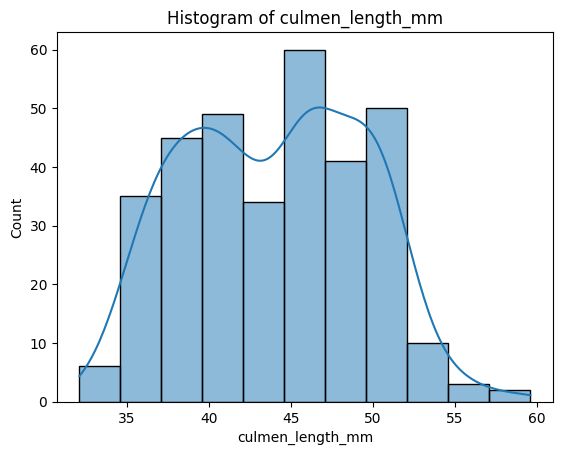

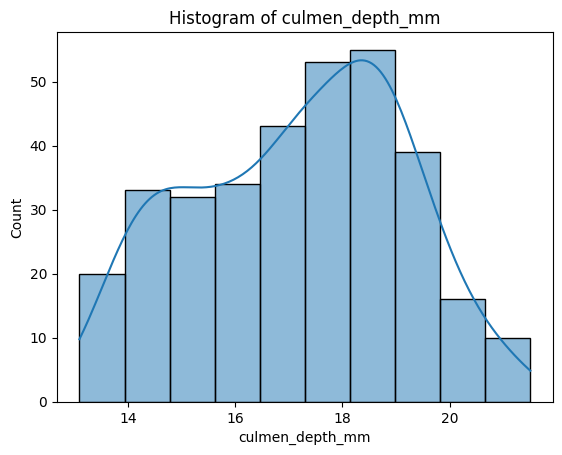

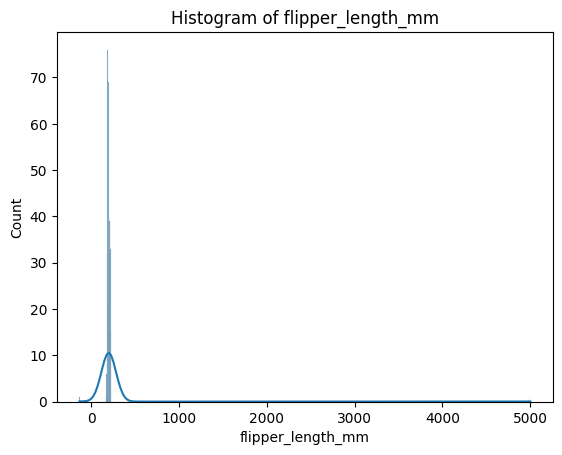

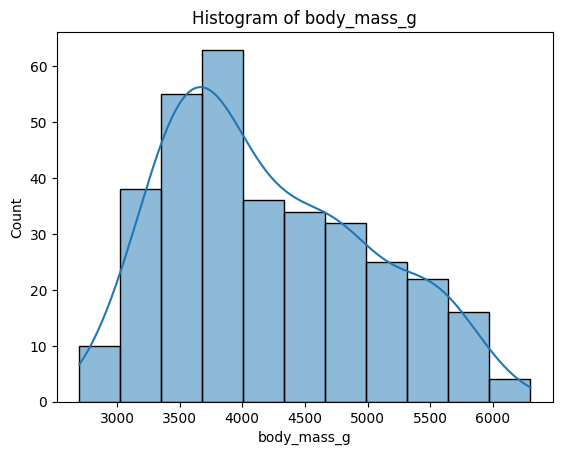

In [209]:
for col in df.columns:
  if col != "sex":
    sns.histplot(df[col], kde = True)
    plt.title(f"Histogram of {col}")
    plt.show()
    print("\n\n\n")

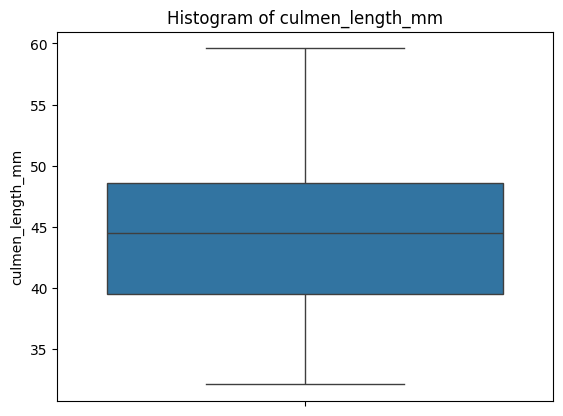

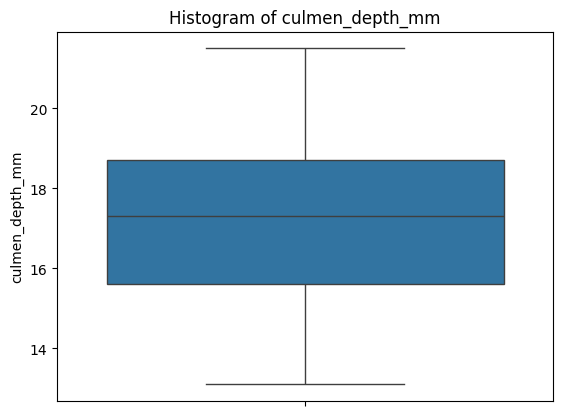

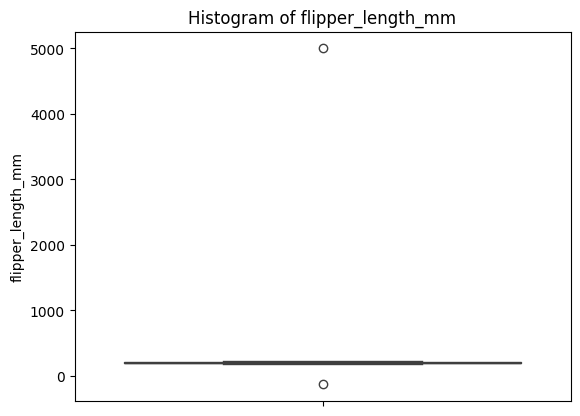

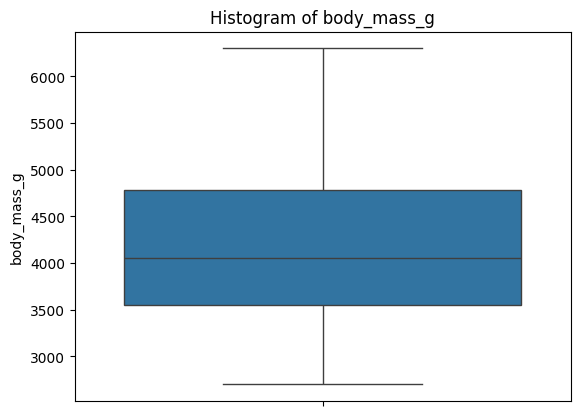

In [210]:
for col in df.columns:
  if col != "sex":
    sns.boxplot(df[col])
    plt.title(f"Histogram of {col}")
    plt.show()
    print("\n\n\n")

In [211]:
#Removing Outlier
Q1 = df['flipper_length_mm'].quantile(0.25)
Q3 = df['flipper_length_mm'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['flipper_length_mm'] >= lower_bound) & (df['flipper_length_mm'] <= upper_bound)]

In [212]:
# removing dot from sex

df = df[df['sex'] != "."]

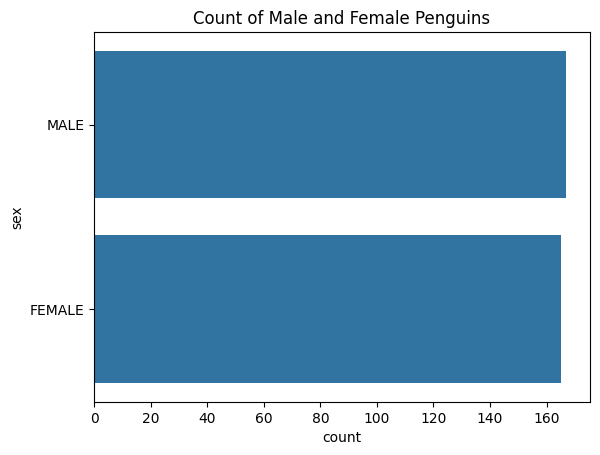

In [213]:
sns.countplot(df["sex"])
plt.title("Count of Male and Female Penguins")
plt.show()

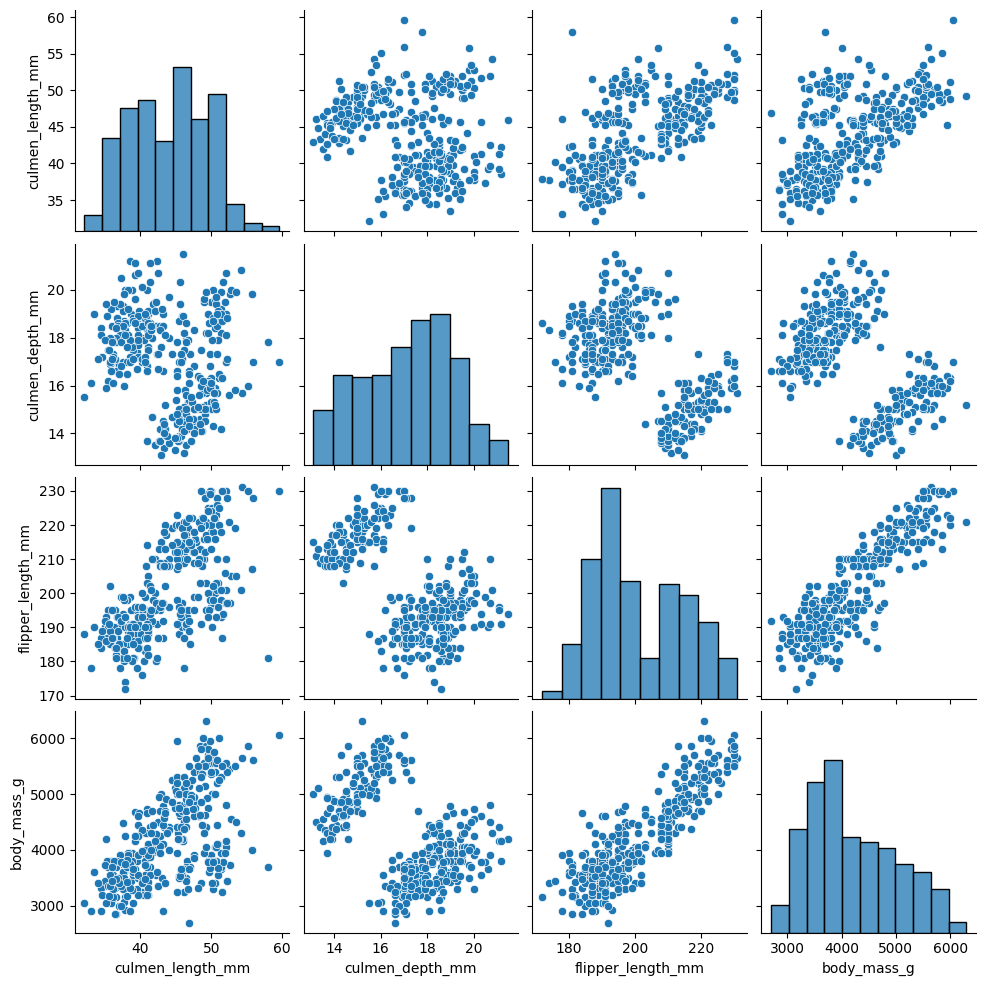

In [214]:
sns.pairplot(df)
plt.show()

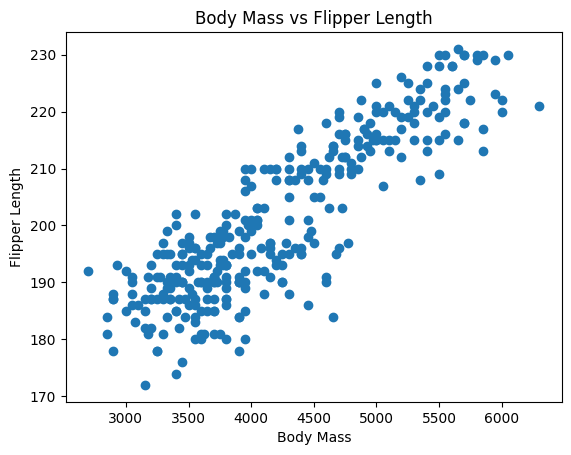

In [215]:
plt.scatter(x = df['body_mass_g'], y = df['flipper_length_mm'])
plt.title("Body Mass vs Flipper Length")
plt.xlabel("Body Mass")
plt.ylabel("Flipper Length")
plt.show()

## Model selection

In [216]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

In [217]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,1


## Scalling

In [218]:
#standard scalling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df['body_mass_g'] = sc.fit_transform(df[['body_mass_g']])
df['flipper_length_mm'] = sc.fit_transform(df[['flipper_length_mm']])
df['culmen_length_mm'] = sc.fit_transform(df[['culmen_length_mm']])
df['culmen_depth_mm'] = sc.fit_transform(df[['culmen_depth_mm']])

In [219]:
df['sex'] = sc.fit_transform(df[['sex']])

In [220]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,-0.903906,0.790360,-1.425342,-0.566948,0.993994
1,-0.830434,0.126187,-1.068577,-0.504847,-1.006042
2,-0.683490,0.432728,-0.426399,-1.187953,-1.006042
4,-1.344738,1.096901,-0.569105,-0.939551,-1.006042
5,-0.867170,1.761074,-0.783164,-0.691149,0.993994


In [221]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
x_pca = pca.fit_transform(df)
print(pca.explained_variance_ratio_)

[0.56820593 0.28153159]


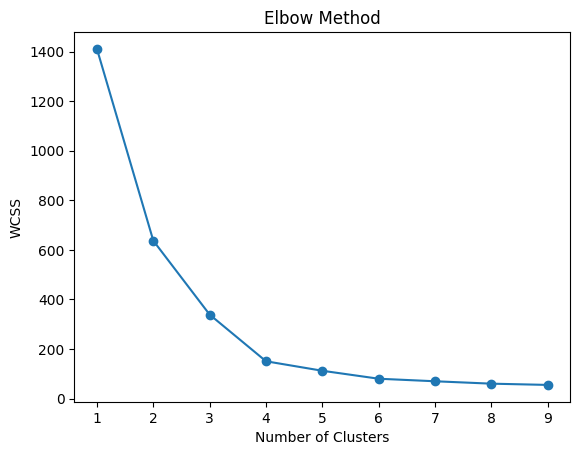

In [222]:
import numpy as np
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 10):
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  kmeans.fit(x_pca)
  wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [223]:
y_kmeans = KMeans(n_clusters = 4, random_state=42)
kmeans = y_kmeans.fit_predict(x_pca)

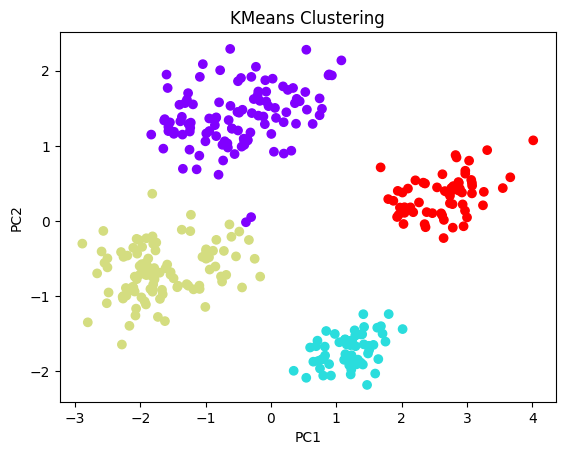

In [224]:
plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c = kmeans,
    cmap = 'rainbow'
)

plt.title("KMeans Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Silhouette score

In [225]:
from sklearn.metrics import silhouette_score

s_score = silhouette_score(x_pca, kmeans)
print(s_score)

0.655150235573714


In [226]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.5, min_samples = 5)
db_cluster = dbscan.fit_predict(x_pca)
set(db_cluster)

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)}

In [227]:
db_score = silhouette_score(x_pca, db_cluster)
print(db_score)

0.6490943825229932


In [228]:
df['db-cluster'] = db_cluster
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,db-cluster
0,-0.903906,0.790360,-1.425342,-0.566948,0.993994,0
1,-0.830434,0.126187,-1.068577,-0.504847,-1.006042,1
2,-0.683490,0.432728,-0.426399,-1.187953,-1.006042,1
4,-1.344738,1.096901,-0.569105,-0.939551,-1.006042,1
5,-0.867170,1.761074,-0.783164,-0.691149,0.993994,0


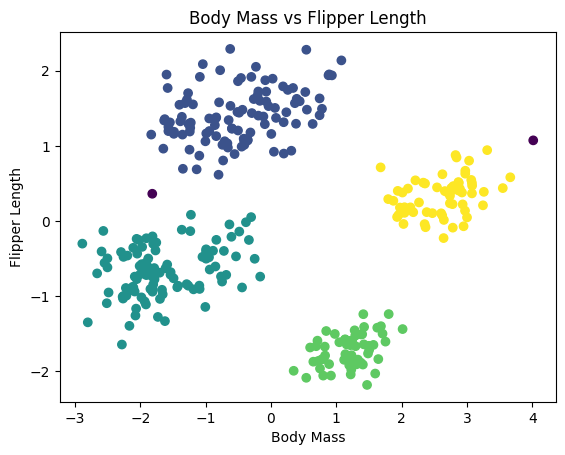

In [229]:
plt.scatter( x_pca[:, 0],
            x_pca[:, 1],
            c = db_cluster)

plt.title("Body Mass vs Flipper Length")
plt.xlabel("Body Mass")
plt.ylabel("Flipper Length")
plt.show()

In [230]:
mask = db_cluster != -1
score = silhouette_score(x_pca[mask], db_cluster[mask])
print(score)

0.6580316657070916
